# Experiment 6: Time Series Forecasting using RNN

**Course:** AML ZC417 – Introduction to Deep Learning
**Module Reference:** Module 8 — Recurrent Neural Networks (RNN, LSTM, GRU)
**Duration:** 2 hours

---

## Aim
To build, train, and evaluate Recurrent Neural Networks (SimpleRNN, LSTM, and GRU) for univariate time series forecasting, and to compare their ability to capture temporal dependencies.

## Learning Outcomes
By the end of this experiment, you will be able to:
1. Prepare a time series for supervised learning using a sliding-window approach.
2. Build and train a SimpleRNN model for forecasting.
3. Build and train LSTM and GRU models, and explain how they address the vanishing gradient problem of a plain RNN.
4. Compare the forecasting accuracy of SimpleRNN, LSTM, and GRU on the same task.
5. Perform multi-step ahead forecasting and evaluate its accuracy against single-step forecasting.
6. Interpret forecasting error using appropriate metrics (MAE, RMSE) and visualizations.


## Part 0 — Setup and Dataset

We generate a **synthetic time series** combining a long-term trend, yearly seasonality, weekly seasonality, and random noise — a pattern representative of many real-world series (sales, temperature, energy demand) while being fully reproducible without any external download.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


Series length: 1460


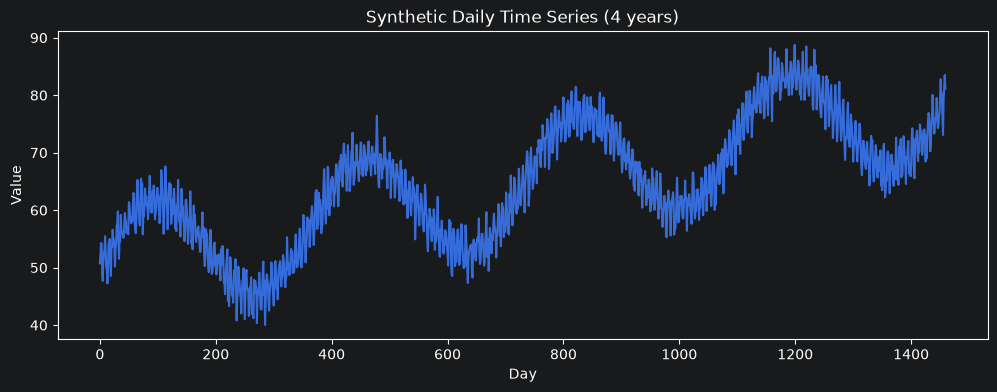

In [2]:
def generate_time_series(n_days=1460):
    t = np.arange(n_days)
    trend = 0.02 * t
    yearly_seasonality = 10 * np.sin(2 * np.pi * t / 365.25)
    weekly_seasonality = 3 * np.sin(2 * np.pi * t / 7)
    noise = np.random.normal(0, 1.5, size=n_days)
    series = 50 + trend + yearly_seasonality + weekly_seasonality + noise
    return series.astype(np.float32)

series = generate_time_series()
print("Series length:", len(series))

plt.figure(figsize=(12, 4))
plt.plot(series)
plt.title("Synthetic Daily Time Series (4 years)")
plt.xlabel("Day"); plt.ylabel("Value")
plt.show()


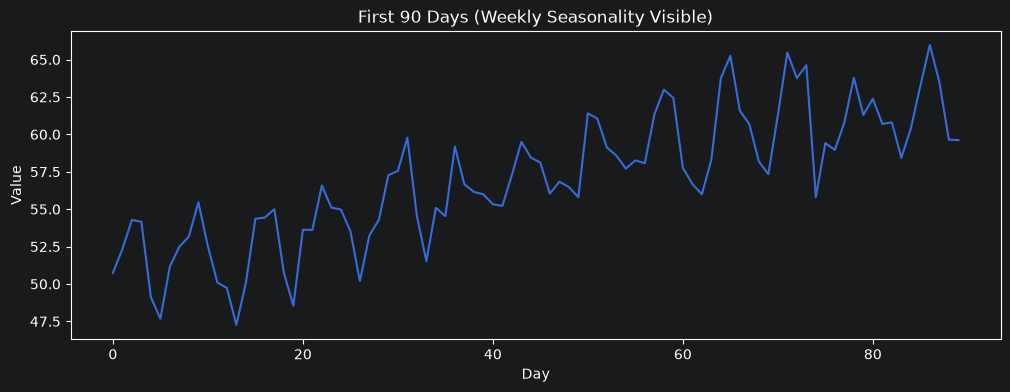

In [3]:
# Zoom into the first 90 days to see the weekly + yearly pattern more clearly
plt.figure(figsize=(12, 4))
plt.plot(series[:90])
plt.title("First 90 Days (Weekly Seasonality Visible)")
plt.xlabel("Day"); plt.ylabel("Value")
plt.show()


---
## Part 1 — Preparing the Data: Sliding-Window Sequences

RNNs learn to map an **input sequence** to an **output** (here, the next value). We convert the raw series into (input_window, target) pairs using a sliding window of length `WINDOW_SIZE`: each input is `WINDOW_SIZE` consecutive past values, and the target is the very next value.


In [4]:
WINDOW_SIZE = 30   # use the last 30 days to predict the next day

def make_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

X, y = make_windows(series, WINDOW_SIZE)
print("X shape:", X.shape, "| y shape:", y.shape)


X shape: (1430, 30) | y shape: (1430,)


In [5]:
# Chronological train/validation/test split (never shuffle time series data!)
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)


Train: (1000, 30) | Val: (215, 30) | Test: (215, 30)


**Important:** Unlike image or tabular data, time series data must **never** be shuffled before splitting — the validation and test sets must come *after* the training period in time, otherwise the model would be evaluated on data that "leaks" information from the future.


In [6]:
# Normalize using statistics from the TRAINING set only (to avoid data leakage)
train_mean = X_train.mean()
train_std = X_train.std()

def normalize(x):
    return (x - train_mean) / train_std

def denormalize(x):
    return x * train_std + train_mean

X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)
y_train_n, y_val_n, y_test_n = normalize(y_train), normalize(y_val), normalize(y_test)

# RNN layers expect input shape (batch, timesteps, features) -- we have 1 feature (univariate)
X_train_n = X_train_n[..., np.newaxis]
X_val_n = X_val_n[..., np.newaxis]
X_test_n = X_test_n[..., np.newaxis]

print("X_train_n shape (batch, timesteps, features):", X_train_n.shape)


X_train_n shape (batch, timesteps, features): (1000, 30, 1)


---
## Part 2 — Naive Baseline (for comparison)

Before building any RNN, we establish a simple **naive baseline**: predict that tomorrow's value equals today's value. Any model we build should clearly outperform this baseline to be worth using.


In [7]:
naive_pred = X_test[:, -1]   # last observed value in each window
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print(f"Naive baseline -- MAE: {naive_mae:.4f}, RMSE: {naive_rmse:.4f}")


Naive baseline -- MAE: 2.3495, RMSE: 2.7977


---
## Part 3 — Building a SimpleRNN Model

A **SimpleRNN** layer processes a sequence one timestep at a time, maintaining a hidden state that is updated at every step and passed forward. In theory, this lets it use information from the entire input window; in practice, plain RNNs struggle to retain information over long sequences due to the **vanishing gradient problem** during backpropagation through time.


In [ ]:
def build_simple_rnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(WINDOW_SIZE, 1)),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

rnn_model = build_simple_rnn()
rnn_model.summary()


In [ ]:
history_rnn = rnn_model.fit(
    X_train_n, y_train_n,
    validation_data=(X_val_n, y_val_n),
    epochs=40,
    batch_size=32,
    verbose=2,
)


In [ ]:
def evaluate_model(model, X_test_n, y_test, name):
    pred_n = model.predict(X_test_n, verbose=0).flatten()
    pred = denormalize(pred_n)   # back to the original scale
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name} -- MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    return pred, mae, rmse

rnn_pred, rnn_mae, rnn_rmse = evaluate_model(rnn_model, X_test_n, y_test, "SimpleRNN")


---
## Part 4 — Building an LSTM Model

**Long Short-Term Memory (LSTM)** networks add a separate **cell state** and three gates (input, forget, output) that explicitly control what information is retained, discarded, or output at each timestep. This gating mechanism allows LSTMs to preserve relevant information over much longer sequences than a plain RNN, largely avoiding the vanishing gradient problem.


In [ ]:
def build_lstm():
    model = keras.Sequential([
        keras.layers.Input(shape=(WINDOW_SIZE, 1)),
        keras.layers.LSTM(32),
        keras.layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

lstm_model = build_lstm()
history_lstm = lstm_model.fit(
    X_train_n, y_train_n,
    validation_data=(X_val_n, y_val_n),
    epochs=40,
    batch_size=32,
    verbose=2,
)


In [ ]:
lstm_pred, lstm_mae, lstm_rmse = evaluate_model(lstm_model, X_test_n, y_test, "LSTM")


---
## Part 5 — Building a GRU Model

**Gated Recurrent Unit (GRU)** is a simplified alternative to LSTM: it combines the forget and input gates into a single "update gate" and merges the cell state and hidden state. GRUs have fewer parameters than LSTMs and often train faster, while achieving comparable performance on many tasks.


In [ ]:
def build_gru():
    model = keras.Sequential([
        keras.layers.Input(shape=(WINDOW_SIZE, 1)),
        keras.layers.GRU(32),
        keras.layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

gru_model = build_gru()
history_gru = gru_model.fit(
    X_train_n, y_train_n,
    validation_data=(X_val_n, y_val_n),
    epochs=40,
    batch_size=32,
    verbose=2,
)


In [ ]:
gru_pred, gru_mae, gru_rmse = evaluate_model(gru_model, X_test_n, y_test, "GRU")


---
## Part 6 — Comparing All Models


In [ ]:
print(f"{'Model':<15}{'MAE':>10}{'RMSE':>10}")
print("-" * 35)
print(f"{'Naive':<15}{naive_mae:>10.4f}{naive_rmse:>10.4f}")
print(f"{'SimpleRNN':<15}{rnn_mae:>10.4f}{rnn_rmse:>10.4f}")
print(f"{'LSTM':<15}{lstm_mae:>10.4f}{lstm_rmse:>10.4f}")
print(f"{'GRU':<15}{gru_mae:>10.4f}{gru_rmse:>10.4f}")


In [ ]:
# Plot actual vs. predicted values for the test period
plt.figure(figsize=(13, 5))
plt.plot(y_test, label="Actual", linewidth=2, color="black")
plt.plot(rnn_pred, label="SimpleRNN", alpha=0.7)
plt.plot(lstm_pred, label="LSTM", alpha=0.7)
plt.plot(gru_pred, label="GRU", alpha=0.7)
plt.title("Actual vs. Predicted -- Test Period")
plt.xlabel("Time step (test set)"); plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Bar chart comparing MAE across all models
models = ["Naive", "SimpleRNN", "LSTM", "GRU"]
maes = [naive_mae, rnn_mae, lstm_mae, gru_mae]

plt.figure(figsize=(7, 4))
plt.bar(models, maes, color=["gray", "steelblue", "darkorange", "seagreen"])
plt.ylabel("MAE (lower is better)")
plt.title("Forecasting Error Comparison")
plt.tight_layout()
plt.show()


**What to look for:** All three RNN variants should outperform the naive baseline, since the naive baseline ignores the yearly/weekly seasonality entirely. LSTM and GRU often perform similarly to (or slightly better than) SimpleRNN on a task like this with a 30-day window, since the relevant patterns (weekly cycle, slow trend) are not so long that a plain RNN cannot capture at least the short-term component.


---
## Part 7 — Multi-Step Ahead Forecasting

So far we have only predicted **one day ahead**. In many real applications, we need to forecast several steps into the future. One common approach is **recursive forecasting**: predict one step ahead, append that prediction to the input window, drop the oldest value, and repeat.


In [ ]:
def recursive_forecast(model, initial_window, n_steps):
    window = initial_window.copy()   # shape (WINDOW_SIZE,), original scale
    forecasts = []
    for _ in range(n_steps):
        window_n = normalize(window)[np.newaxis, :, np.newaxis]
        next_pred_n = model.predict(window_n, verbose=0)[0, 0]
        next_pred = denormalize(next_pred_n)
        forecasts.append(next_pred)
        window = np.append(window[1:], next_pred)   # slide the window forward
    return np.array(forecasts)

N_STEPS_AHEAD = 14
initial_window = X_test[0]              # first test window, original scale
true_future = series[val_end + WINDOW_SIZE : val_end + WINDOW_SIZE + N_STEPS_AHEAD]

forecast_lstm = recursive_forecast(lstm_model, initial_window, N_STEPS_AHEAD)

plt.figure(figsize=(9, 4))
plt.plot(range(N_STEPS_AHEAD), true_future, label="Actual", marker="o")
plt.plot(range(N_STEPS_AHEAD), forecast_lstm, label="LSTM Recursive Forecast", marker="x")
plt.title(f"{N_STEPS_AHEAD}-Day Ahead Recursive Forecast (LSTM)")
plt.xlabel("Days ahead"); plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

multi_step_mae = mean_absolute_error(true_future, forecast_lstm)
print(f"14-day recursive forecast MAE: {multi_step_mae:.4f} (compare to 1-day MAE: {lstm_mae:.4f})")


**What to look for:** Multi-step recursive forecasting error typically **grows** with the forecast horizon, since each prediction is based partly on the model's own earlier (imperfect) predictions rather than true observed values — small errors accumulate. This is why the 14-day MAE is usually noticeably higher than the 1-day MAE.


---
## Part 8 — In-Lab Exercise (to be completed and shown to the instructor)

1. Change `WINDOW_SIZE` to **7** (one week) and to **60** (two months), retrain the LSTM model for each, and report test MAE for both. Which window size works best for this series, and why might that be, given how the series was generated?
2. Build a **stacked LSTM** (two LSTM layers, e.g. `LSTM(32, return_sequences=True)` followed by `LSTM(32)`) and compare its test MAE to the single-layer LSTM from Part 4.
3. Repeat the recursive multi-step forecast from Part 7 using the **GRU** model instead of LSTM, for the same 14-day horizon. Compare its multi-step MAE to the LSTM's.
4. Add **Gaussian noise with double the standard deviation** (`np.random.normal(0, 3.0, ...)`) when generating the series in Part 0, regenerate all datasets, and retrain the LSTM. How does the noisier series affect the naive baseline's MAE compared to the LSTM's MAE? What does this suggest about when RNNs provide the most benefit over naive forecasting?
5. In 3–4 sentences, summarize which model (SimpleRNN, LSTM, or GRU) performed best in your experiments, and whether the difference was large or small — and propose one reason for your observation.


In [ ]:
# TODO 1: WINDOW_SIZE = 7 and WINDOW_SIZE = 60 experiments
# your code here


_TODO 1 (continued): Your explanation here._

In [ ]:
# TODO 2: Stacked LSTM (two layers)
# your code here


In [ ]:
# TODO 3: Recursive multi-step forecast using GRU
# your code here


In [ ]:
# TODO 4: Noisier series experiment
# your code here


_TODO 4 (continued): Your explanation here._

_TODO 5: Your summary here._

---
## Post-Lab Viva Questions

1. Why must time series data be split chronologically rather than randomly shuffled before training?
2. Why do we normalize using statistics computed only from the training set, rather than the entire dataset?
3. What is the vanishing gradient problem, and why does it particularly affect plain RNNs on long sequences?
4. Name the three gates in an LSTM cell and briefly describe what each one controls.
5. How does a GRU differ structurally from an LSTM, and what is the practical trade-off between the two?
6. Why does error typically increase with forecast horizon in recursive multi-step forecasting?
7. Why is comparing against a naive baseline (e.g. "tomorrow = today") an important first step before trusting a more complex model's results?

---
*End of Experiment 6*
